# 🧠 Section 06. 모델 성능 진단·개선 및 Grad-CAM
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- EarlyStopping으로 과적합을 조기에 탐지하고 학습을 종료한다
- LR Scheduler(StepLR, CosineAnnealing, ReduceLROnPlateau)를 비교한다
- PyTorch hooks로 Grad-CAM을 구현하고 예측 근거를 시각화한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | Oxford 102 Flowers (Section 05 연속) |
| 크기 | 8,189장 / 102 클래스 |
| 출처 | `torchvision.datasets.Flowers102` |

## ⚙️ 실습 전 필수 확인 — 로컬 환경 설정

이 노트북은 `environment.yml`로 생성한 가상환경에서 실행합니다.

```bash
conda env create -f environment.yml
conda activate cnn-course
jupyter lab
```

> GPU가 있는 경우 자동으로 CUDA를 사용합니다.

✅ 적용 폰트: NanumGothic
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 138 not upgraded.
✅ NanumGothic 적용 완료


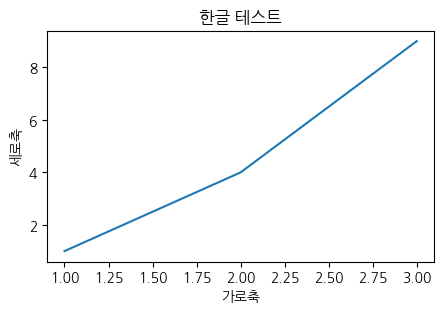

In [22]:
# ─────────────────────────────────────────────
# 한글 폰트 자동 설정 (Mac / Linux / Colab 대응)
# ─────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 현재 설치된 폰트 이름 출력
font_list = [f.name for f in fm.fontManager.ttflist]

# 사용할 후보 폰트
candidate_fonts = [
    'AppleGothic',      # Mac
    'Malgun Gothic',    # Windows
    'NanumGothic',      # Linux/Colab
    'DejaVu Sans'
]

selected_font = None

for font in candidate_fonts:
    if font in font_list:
        selected_font = font
        break

# 폰트 적용
if selected_font:
    plt.rcParams['font.family'] = selected_font
    print(f"✅ 적용 폰트: {selected_font}")
else:
    print("❌ 사용 가능한 한글 폰트를 찾지 못했습니다.")

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

!apt-get install -y fonts-nanum

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ NanumGothic 적용 완료")

plt.figure(figsize=(5,3))
plt.title("한글 테스트")
plt.plot([1,2,3], [1,4,9])
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.show()

In [7]:
# ⚙️ 환경 설정 (반드시 가장 먼저 실행하세요)
import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim, torchvision
import torchvision.transforms as transforms, torchvision.models as models
import matplotlib.pyplot as plt, numpy as np
from torchvision.datasets import Flowers102
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device} | PyTorch: {torch.__version__}")

✅ Device: cuda | PyTorch: 2.7.0+cu128


/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 📁 데이터셋 및 모델 재사용 (Section 05 연속)

Section 05에서 구성한 Flowers102 DataLoader와 Fine-tuned ResNet-50을 그대로 재사용합니다.

### 📖 이번 섹션에서 배우는 것

| 기법 | 목적 | 핵심 질문 |
|---|---|---|
| EarlyStopping | 과적합 방지 | 언제 학습을 멈춰야 하나? |
| LR Scheduler | 학습률 동적 조절 | 학습률을 어떻게 바꿔야 빨리 수렴하나? |
| Grad-CAM | 예측 근거 시각화 | 모델이 어디를 보고 판단했나? |

> 💡 **핵심 직관**  
> 지금까지 모델을 만들고 학습했다면, 이번엔 "잘 만들어졌는지 진단"하고  
> "더 잘 학습되도록 개선"하는 도구들을 배웁니다.  
> 실무에서는 모델 설계만큼 이 진단·개선 과정이 중요합니다.

In [8]:
# ─────────────────────────────────────────────
# 데이터 로드 (Section 05와 동일 설정)
# ─────────────────────────────────────────────
MEAN=(0.485,0.456,0.406); STD=(0.229,0.224,0.225)
tfm_train=transforms.Compose([
    transforms.RandomResizedCrop(224),transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])
tfm_val=transforms.Compose([
    transforms.Resize(256),transforms.CenterCrop(224),
    transforms.ToTensor(),transforms.Normalize(MEAN,STD)])

train_set=Flowers102('./data','train',download=True,transform=tfm_train)
val_set  =Flowers102('./data','val',  download=True,transform=tfm_val)
test_set =Flowers102('./data','test', download=True,transform=tfm_val)

train_loader=DataLoader(train_set,32,shuffle=True,num_workers=2)
val_loader  =DataLoader(val_set,  32,shuffle=False,num_workers=2)
test_loader =DataLoader(test_set, 32,shuffle=False,num_workers=2)
print(f"Train:{len(train_set)} / Val:{len(val_set)} / Test:{len(test_set)}")

Train:1020 / Val:1020 / Test:6149


---
## 실습 1. EarlyStopping 구현

### 📖 왜 EarlyStopping이 필요한가?

에포크를 늘릴수록 Train Loss는 계속 낮아지지만, 어느 순간부터 **Val Loss가 올라가기 시작합니다.**  
이 시점이 과적합의 시작입니다. EarlyStopping은 이 순간을 자동으로 감지합니다.

```
에포크 1~15:  Train Loss↓  Val Loss↓  → 정상 학습
에포크 16~20: Train Loss↓  Val Loss↑  → 과적합 시작 ← 여기서 멈춰야 함!
에포크 21~30: Train Loss↓↓ Val Loss↑↑ → 과적합 심화
```

> 💡 **핵심 직관**  
> 시험 전날 벼락치기를 한다고 상상하세요.  
> 처음에는 공부할수록 시험 점수가 오르지만, 너무 오래 하면 오히려 지쳐서 점수가 떨어집니다.  
> EarlyStopping은 "피크일 때 멈추는 것"입니다.

> ⚠️ **반드시 기억**: EarlyStopping이 발동된 후에는  
> `model.load_state_dict(torch.load('best_model.pt'))`로 **최적 가중치를 복원**해야 합니다.  
> 학습이 멈춘 시점의 가중치는 이미 약간 과적합된 상태일 수 있습니다.

### ✏️ TODO: `EarlyStopping` 클래스 구현

In [9]:
# ─────────────────────────────────────────────
# TODO: EarlyStopping 클래스 구현
# ─────────────────────────────────────────────

class EarlyStopping:
    """
    Validation loss가 개선되지 않으면 학습을 조기 종료하는 콜백.

    Args:
        patience (int): 개선 없이 허용하는 최대 에포크 수
        delta    (float): 개선으로 인정하는 최소 변화량
        path     (str): 최적 모델 저장 경로
    """
    def __init__(self, patience=5, delta=0.0, path='best_model.pt'):
        self.patience = patience
        self.delta    = delta
        self.path     = path
        self.counter  = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        """
        Args:
            val_loss (float): 현재 에포크의 검증 손실
            model (nn.Module): 저장할 모델

        Returns:
            None (self.early_stop를 True로 설정)
        """
        if self.best_loss is None:
            self.best_loss = val_loss
            self._save(model)
        elif val_loss > self.best_loss - ___:  # 힌트: self.delta보다 개선이 없으면 counter 증가
            self.counter += 1
            print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= ___:            # 힌트: patience 횟수 초과 시 종료
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self._save(model)
            self.counter = 0   # 개선됐으므로 counter 리셋

    def _save(self, model):
        torch.save(model.state_dict(), self.path)
        print(f"  ✅ 모델 저장: val_loss={self.best_loss:.4f}")

print("EarlyStopping 클래스를 완성한 뒤 다음 셀을 실행하세요!")

EarlyStopping 클래스를 완성한 뒤 다음 셀을 실행하세요!


In [10]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
class EarlyStopping:
    def __init__(self,patience=5,delta=0.0,path='best_model.pt'):
        self.patience=patience; self.delta=delta; self.path=path
        self.counter=0; self.best_loss=None; self.early_stop=False
    def __call__(self,val_loss,model):
        if self.best_loss is None:
            self.best_loss=val_loss; self._save(model)
        elif val_loss > self.best_loss - self.delta:
            self.counter+=1
            print(f"  EarlyStopping: {self.counter}/{self.patience}")
            if self.counter>=self.patience: self.early_stop=True
        else:
            self.best_loss=val_loss; self._save(model); self.counter=0
    def _save(self,model): torch.save(model.state_dict(),self.path)
print("✅ EarlyStopping 정답 로드!")

✅ EarlyStopping 정답 로드!


In [11]:
# ─────────────────────────────────────────────
# 1-1. EarlyStopping 학습 루프
# ─────────────────────────────────────────────
model_es = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model_es.fc = nn.Linear(model_es.fc.in_features, 102)
model_es = model_es.to(device)

optimizer = optim.Adam(model_es.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
es = EarlyStopping(patience=4, delta=1e-3, path='best_model.pt')

hist_es = {"train_loss":[], "val_loss":[], "val_acc":[]}

for epoch in tqdm(range(1, 30)):
    model_es.train()
    tl = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_es(imgs), labels)
        loss.backward(); optimizer.step()
        tl += loss.item()

    model_es.eval(); vl, vc, vt = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_es(imgs)
            vl += criterion(out, labels).item()
            vc += out.argmax(1).eq(labels).sum().item()
            vt += labels.size(0)

    avg_vl = vl/len(val_loader)
    hist_es["train_loss"].append(tl/len(train_loader))
    hist_es["val_loss"].append(avg_vl)
    hist_es["val_acc"].append(vc/vt)
    print(f"Epoch {epoch:2d} | Train Loss: {tl/len(train_loader):.4f} | Val Loss: {avg_vl:.4f} | Val Acc: {vc/vt*100:.2f}%")

    es(avg_vl, model_es)
    if es.early_stop:
        print(f"\n🛑 EarlyStopping: {epoch} 에포크에서 조기 종료")
        break

# 최적 가중치 복원
model_es.load_state_dict(torch.load('best_model.pt'))
print("✅ 최적 모델 가중치 복원 완료")

  3%|▎         | 1/29 [00:03<01:31,  3.28s/it]

Epoch  1 | Train Loss: 4.2948 | Val Loss: 3.1750 | Val Acc: 51.18%


  7%|▋         | 2/29 [00:06<01:26,  3.19s/it]

Epoch  2 | Train Loss: 2.9111 | Val Loss: 1.9081 | Val Acc: 73.24%


 10%|█         | 3/29 [00:09<01:21,  3.13s/it]

...

Epoch 12 | Train Loss: 0.2196 | Val Loss: 0.3593 | Val Acc: 93.14%
  EarlyStopping: 2/4


 45%|████▍     | 13/29 [00:40<00:49,  3.08s/it]

Epoch 13 | Train Loss: 0.2024 | Val Loss: 0.3407 | Val Acc: 93.14%
  EarlyStopping: 3/4


 45%|████▍     | 13/29 [00:43<00:53,  3.35s/it]

Epoch 14 | Train Loss: 0.2170 | Val Loss: 0.3452 | Val Acc: 92.65%
  EarlyStopping: 4/4

🛑 EarlyStopping: 14 에포크에서 조기 종료
✅ 최적 모델 가중치 복원 완료


---
## 실습 2. LR Scheduler 비교

### 📖 왜 학습률을 바꿔야 하는가?

> 💡 **핵심 직관**  
> 등산할 때를 생각해보세요.  
> 처음에는 큰 걸음으로 빠르게 이동하고(큰 lr),  
> 정상 근처에서는 작은 걸음으로 정확하게 자리를 잡습니다(작은 lr).  
> 고정 학습률은 "처음부터 끝까지 같은 걸음걸이"로 걷는 것입니다.

### 📖 세 가지 스케줄러 비교

| Scheduler | 방식 | 언제 줄이나 | 특징 |
|---|---|---|---|
| StepLR | 매 N 에포크마다 γ 배 | 정기적으로 | 단순, 예측 가능 |
| CosineAnnealingLR | 코사인 곡선으로 감소 | 부드럽게 | 실무 표준 |
| ReduceLROnPlateau | Val loss 정체 감지 시 | 자동으로 | 적응적, 편리 |

> ⚠️ **자주 하는 실수**:  
> `ReduceLROnPlateau`는 `scheduler.step()`이 아닌 `scheduler.step(val_loss)`로 호출합니다.  
> 인자 없이 호출하면 에러가 발생합니다.

아래 코드는 실제 학습 없이 학습률 변화 패턴만 시뮬레이션합니다.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

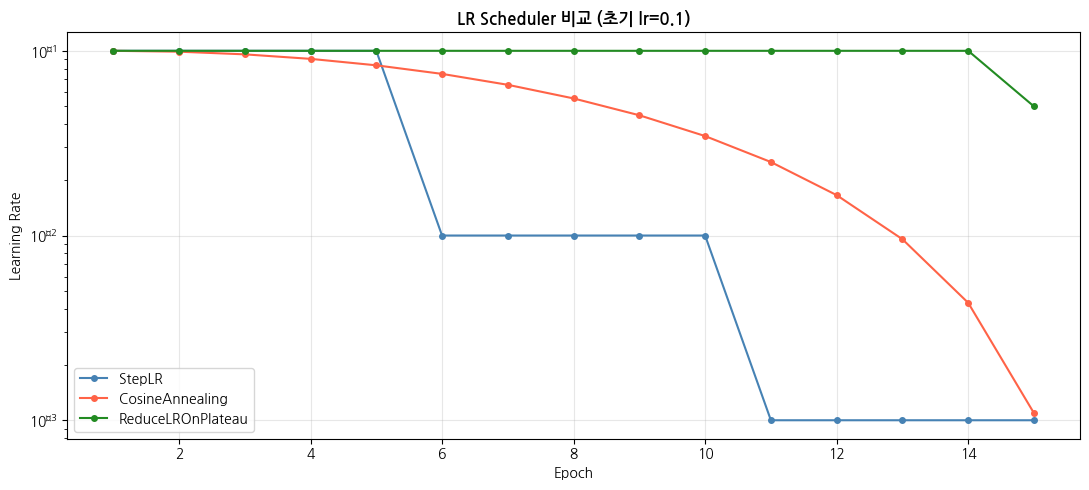

💡 각 스케줄러의 특징:
  StepLR: 일정 주기마다 lr을 gamma 배 감소 → 단순, 예측 가능
  CosineAnnealing: 코사인 곡선으로 부드럽게 감소 → 실무에서 많이 사용
  ReduceLROnPlateau: val_loss 개선 없을 때 감소 → 적응적, 자동화


In [23]:
# ─────────────────────────────────────────────
# 2-1. 세 가지 LR Scheduler 비교
# ─────────────────────────────────────────────
def get_lr_history(scheduler_name, epochs=15):
    """스케줄러별 학습률 변화를 기록한다."""
    dummy_model = models.resnet50(weights=None)
    dummy_model.fc = nn.Linear(dummy_model.fc.in_features, 102)
    opt = optim.SGD(dummy_model.parameters(), lr=0.1, momentum=0.9)

    if scheduler_name == "StepLR":
        sched = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.1)
    elif scheduler_name == "CosineAnnealing":
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    elif scheduler_name == "ReduceLROnPlateau":
        sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3)

    lrs = []
    fake_losses = [0.9,0.85,0.8,0.76,0.74,0.73,0.72,0.71,0.71,0.70,0.70,0.70,0.70,0.70,0.70]
    for epoch in range(epochs):
        lrs.append(opt.param_groups[0]['lr'])
        if scheduler_name == "ReduceLROnPlateau":
            sched.step(fake_losses[epoch])
        else:
            sched.step()
    return lrs

names = ["StepLR", "CosineAnnealing", "ReduceLROnPlateau"]
plt.figure(figsize=(11, 5))
colors = ['steelblue', 'tomato', 'forestgreen']
for name, color in zip(names, colors):
    lrs = get_lr_history(name)
    plt.plot(range(1, len(lrs)+1), lrs, marker='o', markersize=4, label=name, color=color)
plt.xlabel("Epoch"); plt.ylabel("Learning Rate")
plt.title("LR Scheduler 비교 (초기 lr=0.1)", fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.yscale('log'); plt.tight_layout(); plt.show()

print("💡 각 스케줄러의 특징:")
print("  StepLR: 일정 주기마다 lr을 gamma 배 감소 → 단순, 예측 가능")
print("  CosineAnnealing: 코사인 곡선으로 부드럽게 감소 → 실무에서 많이 사용")
print("  ReduceLROnPlateau: val_loss 개선 없을 때 감소 → 적응적, 자동화")

---
## 실습 3. Grad-CAM 구현 및 시각화

### 📖 Grad-CAM이 필요한 이유

모델이 높은 정확도를 보여도 "올바른 이유로 맞추는 건지" 알 수 없습니다.  
예를 들어 배경의 눈밭을 보고 "늑대"라고 예측할 수 있습니다.  
Grad-CAM은 **"모델이 어느 부분을 보고 판단했는가"** 를 히트맵으로 시각화합니다.

### 📖 Grad-CAM 동작 원리 3단계

```
① Forward:  이미지 → 모델 통과 → 마지막 Conv 레이어의 특징 맵 저장

② Backward: 예측 클래스 점수 → 역전파
            → 그 특징 맵의 각 채널이 예측에 얼마나 기여했는지 (그래디언트) 계산

③ CAM 생성: (그래디언트 평균 × 특징 맵) 가중합 → ReLU → 히트맵
```

> 💡 **핵심 직관**  
> "귀를 보고 고양이라고 판단했다"면 귀 부분의 활성화가 높습니다.  
> "배경 소파를 보고 고양이라고 판단했다"면 소파 부분이 밝게 나옵니다.  
> 후자라면 모델이 잘못된 특징에 의존하는 것이므로 데이터나 학습을 재검토해야 합니다.

> ⚠️ **구현 주의**: PyTorch hooks는 `register_forward_hook`과 `register_full_backward_hook`을 사용합니다.  
> `backward_hook`은 `register_backward_hook`(deprecated)이 아닌  
> `register_full_backward_hook`을 사용하세요.

In [19]:
# ─────────────────────────────────────────────
# 3-1. GradCAM 클래스 구현
# ─────────────────────────────────────────────

class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    지정한 레이어의 그래디언트와 활성화 맵으로 히트맵을 생성합니다.

    Args:
        model (nn.Module): 시각화할 모델
        target_layer: 활성화 맵을 추출할 레이어
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None

        # forward hook: 해당 레이어 출력(활성화) 저장
        target_layer.register_forward_hook(
            lambda m, inp, out: setattr(self, 'activations', out.detach())
        )
        # backward hook: 해당 레이어 그래디언트 저장
        target_layer.register_full_backward_hook(
            lambda m, grad_in, grad_out: setattr(self, 'gradients', grad_out[0].detach())
        )

    def __call__(self, x, class_idx=None):
        """
        Args:
            x (Tensor): 입력 이미지 (1, C, H, W)
            class_idx (int, optional): 시각화할 클래스 인덱스 (None이면 예측 클래스)

        Returns:
            np.ndarray: 정규화된 CAM 히트맵 (H, W), 0~1
        """
        self.model.eval()
        logits = self.model(x)

        if class_idx is None:
            class_idx = logits.argmax(1).item()

        # 해당 클래스 점수에 대한 역전파
        self.model.zero_grad()
        logits[0, class_idx].backward()

        # 그래디언트 전역 평균 풀링 → 각 채널의 중요도
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)  # (1, 1, H, W)
        cam = F.relu(cam)

        # 정규화 (0~1)
        #cam = cam.squeeze().numpy()
        cam = cam.squeeze().detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

print("✅ GradCAM 클래스 정의 완료")

✅ GradCAM 클래스 정의 완료


In [15]:

!pip install opencv-python-headless

Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92


In [16]:
import cv2
print(cv2.__version__)

4.13.0


/tmp/ipykernel_31459/91481250.py:36: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_31459/91481250.py:36: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_31459/91481250.py:36: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_31459/91481250.py:36: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_31459/91481250.py:36: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_31459/91481250.py:36: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_31459/91481250.py:36: UserWarning: Glyph 52769 (\N{HAN

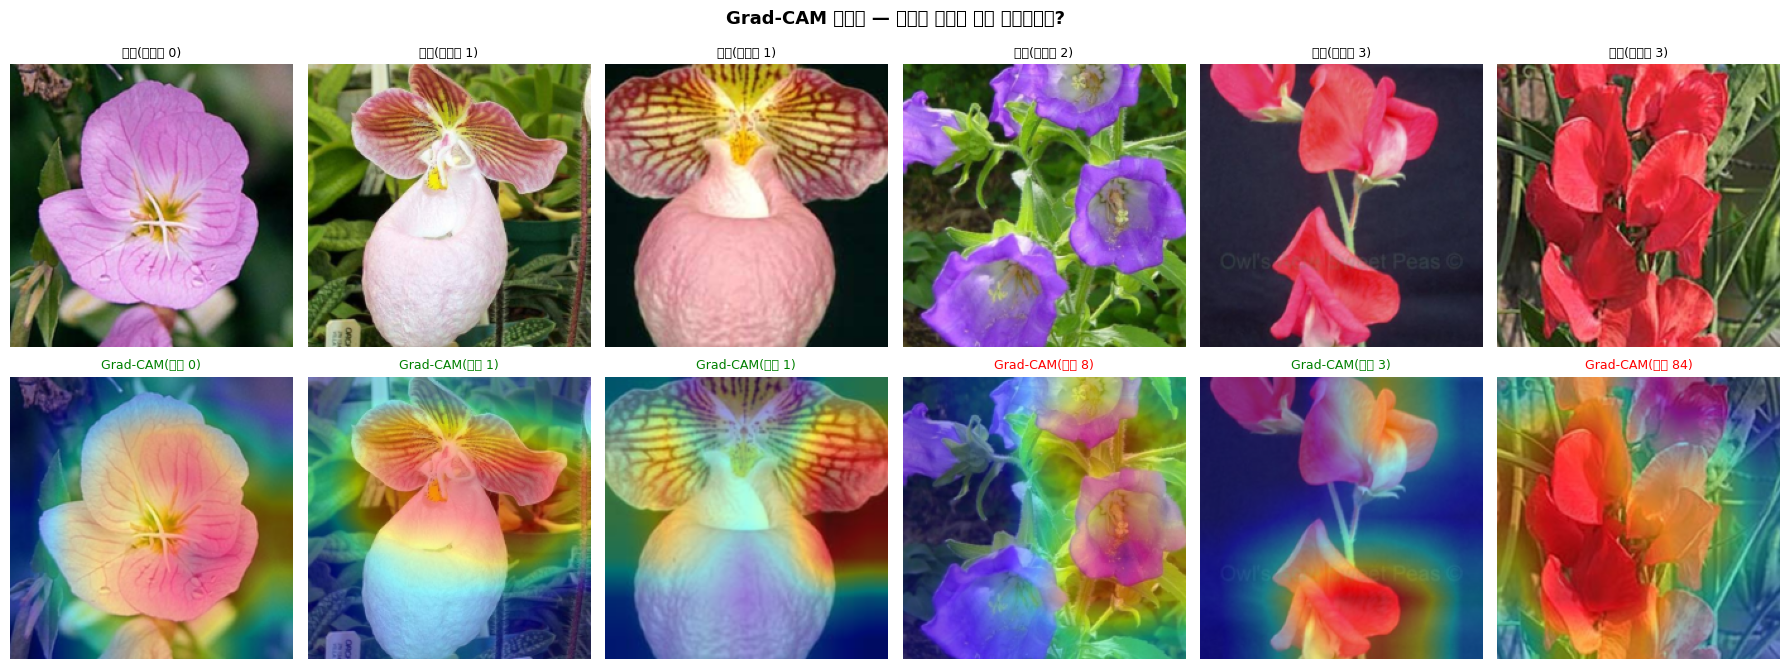

In [20]:
# ─────────────────────────────────────────────
# 3-2. Grad-CAM 시각화
# ─────────────────────────────────────────────
import cv2

gradcam = GradCAM(model_es, model_es.layer4[-1].conv2)

test_raw = Flowers102('./data','test',download=True,transform=transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor()]))

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
for col in range(6):
    img_raw, label = test_raw[col*20]
    img_tensor = tfm_val(transforms.ToPILImage()(img_raw)).unsqueeze(0).to(device)

    cam, pred_idx = gradcam(img_tensor)

    # ✏️ 빈칸: CAM을 원본 이미지 크기로 리사이즈하고 컬러맵 적용
    cam_resized = cv2.resize(cam, (224, 224))   # 힌트: cam (2D 배열)을 원본 크기로 리사이즈
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    original = img_raw.permute(1,2,0).numpy()
    overlay  = (original * 0.6 + heatmap/255 * 0.4).clip(0,1)

    axes[0][col].imshow(original)
    axes[0][col].set_title(f"원본(클래스 {label})", fontsize=9)
    axes[0][col].axis('off')

    axes[1][col].imshow(overlay)
    axes[1][col].set_title(f"Grad-CAM(예측 {pred_idx})", fontsize=9,
                            color='green' if pred_idx==label else 'red')
    axes[1][col].axis('off')

plt.suptitle("Grad-CAM 시각화 — 모델이 어디를 보고 예측하는가?", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [21]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
# cam_resized = cv2.resize(cam, (224, 224))
# → cam은 (7,7) 크기의 NumPy 배열 → (224,224)로 업스케일
print("cam_resized = cv2.resize(cam, (224, 224))")

cam_resized = cv2.resize(cam, (224, 224))


---
## 🚀 도전 과제

### 과제 1. 오분류 샘플 Grad-CAM
모델이 오분류한 샘플의 Grad-CAM을 시각화하고, 모델이 엉뚱한 영역을 보고 있는지 확인하세요.

### 과제 2. 여러 레이어 비교
`layer1`, `layer2`, `layer3`, `layer4` 각각에서 GradCAM을 추출하고  
레이어 깊이에 따라 활성화 영역이 어떻게 달라지는지 비교하세요.

### 과제 3. WarmupScheduler
처음 5 에포크는 학습률을 선형으로 증가시키고 이후 CosineAnnealing을 적용하는  
WarmupCosineScheduler를 구현하고 학습 곡선을 비교하세요.
